In [16]:
# --- INSTALASI ---
!pip install pandas numpy matplotlib tensorflow scikit-learn openpyxl

# --- BAGIAN 1: IMPORT ---=
import pandas as pd             # Alat untuk baca tabel data (Excel/CSV)
import numpy as np              # Alat untuk hitungan matematika
import matplotlib.pyplot as plt # Alat untuk menggambar grafik
import math
import sklearn.metrics as metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# alat untuk AI
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# alat untuk mengubah angka besar (misal: Rp 1 Juta) jadi angka kecil (0-1)
# Biar komputernya tidak pusing hitung angka nol yang kebanyakan.
from sklearn.preprocessing import MinMaxScaler

In [17]:
#show data
path = "/content/sample_data/dataaa.xlsx"

df = pd.read_excel(path)

df.head(5)


,Nomor,Tanggal,Pelanggan,Tipe Barang,Qty,Total,Sumber,Notes,Keterangan
0,SL/DKS/2024-0458,2024-03-01,"MARYANTI, IBU",CONWOOD,2,1609200.0,Intheria,REPEAT ORDER,End User
1,SL/DKS/2024-0462,2024-03-01,DGA INTERIOR,BALIAN WALL STORAGE,3,976800.0,Intheria,CS - WEBSITE,Konsultan
2,SL/DKS/2024-0460,2024-03-01,"ROBIN, BPK",BALIAN NAIL FREE,37,8330000.0,Intheria,WALK IN,End User
3,SL/DKS/2024-0527,2024-03-01,ILHAM APLIKATOR,BALIAN WALL STORAGE,3,840000.0,Intheria,REPEAT ORDER,Internal
4,SL/DKS/2024-0461,2024-03-02,"ROBIN, BPK",BALIAN WALL PANEL,45,10083200.0,Intheria,WALK IN,End User


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Nomor        1853 non-null   object        
 1   Tanggal      1853 non-null   datetime64[ns]
 2   Pelanggan    1853 non-null   object        
 3   Tipe Barang  1853 non-null   object        
 4   Qty          1853 non-null   int64         
 5   Total        1853 non-null   float64       
 6   Sumber       1853 non-null   object        
 7   Notes        1853 non-null   object        
 8   Keterangan   1853 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 130.4+ KB


In [19]:
#CLEANING DATA
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

print("FIX APPLIED")
print(df.columns.tolist())

['Nomor', 'Tanggal', 'Pelanggan', 'Tipe Barang', 'Qty', 'Total', 'Sumber', 'Notes', 'Keterangan']
FIX APPLIED
['nomor', 'tanggal', 'pelanggan', 'tipe_barang', 'qty', 'total', 'sumber', 'notes', 'keterangan']


In [20]:
#date parsing
df['tanggal'] = pd.to_datetime(df['tanggal'])
print(df['tanggal'].dtype)

df = df.set_index('tanggal')

datetime64[ns]


In [21]:
df['tipe_barang'] = df['tipe_barang'].str.strip().str.lower().str.replace(' ','_')
print(df['tipe_barang'])

tanggal
2024-03-01                conwood
2024-03-01    balian_wall_storage
2024-03-01       balian_nail_free
2024-03-01    balian_wall_storage
2024-03-02      balian_wall_panel
                     ...         
2025-09-09    balian_wall_storage
2025-09-10    balian_wall_storage
2025-09-11                conwood
2025-09-12    balian_wall_storage
2025-09-12                conwood
Name: tipe_barang, Length: 1853, dtype: object


In [22]:
#preprocessing data
#encoding
mapping = {
    'conwood': 1,
    'shera': 2,
    'balian_nail_free': 3,
    'balian_wall_panel': 4,
    'balian_wall_storage': 5
}

df['tipe_barang_code'] = df['tipe_barang'].map(mapping)
print(df[['tipe_barang_code','tipe_barang']])

            tipe_barang_code          tipe_barang
tanggal                                          
2024-03-01                 1              conwood
2024-03-01                 5  balian_wall_storage
2024-03-01                 3     balian_nail_free
2024-03-01                 5  balian_wall_storage
2024-03-02                 4    balian_wall_panel
...                      ...                  ...
2025-09-09                 5  balian_wall_storage
2025-09-10                 5  balian_wall_storage
2025-09-11                 1              conwood
2025-09-12                 5  balian_wall_storage
2025-09-12                 1              conwood

[1853 rows x 2 columns]


In [23]:
#cek transaksi kosong
transaksi_nol = df[df['total'] == 0]
jumlah_nol_asli = len(transaksi_nol)

print(f"Ada {jumlah_nol_asli} transaksi yang nilainya 0 rupiah di data asli")
if jumlah_nol_asli > 0:
    print("Contoh data 0 di asli:")
    print(transaksi_nol.head())

Ada 0 transaksi yang nilainya 0 rupiah di data asli


In [24]:
df_models = df[['tipe_barang_code','qty','total']].copy()
print(df_models)

            tipe_barang_code  qty       total
tanggal                                      
2024-03-01                 1    2   1609200.0
2024-03-01                 5    3    976800.0
2024-03-01                 3   37   8330000.0
2024-03-01                 5    3    840000.0
2024-03-02                 4   45  10083200.0
...                      ...  ...         ...
2025-09-09                 5    8   1948200.0
2025-09-10                 5   30   6158240.0
2025-09-11                 1    6   2484312.0
2025-09-12                 5    8    976500.0
2025-09-12                 1    1    760500.0

[1853 rows x 3 columns]


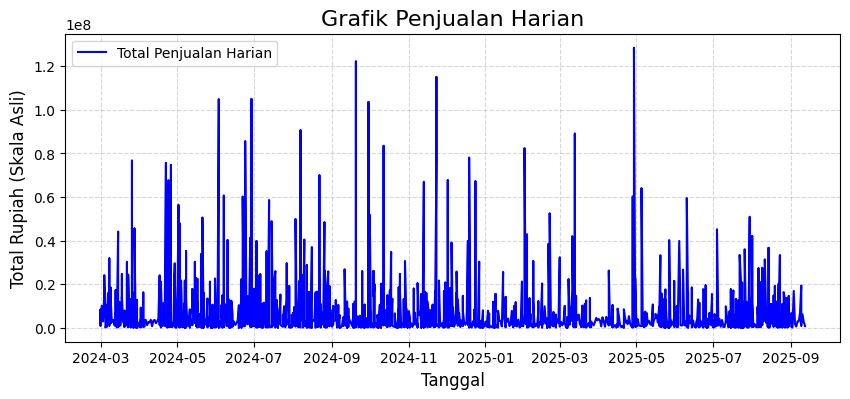

In [25]:
# Atur ukuran gambar biar lebar dan jelas
plt.figure(figsize=(10, 4))

# Plot data: Sumbu X = Tanggal, Sumbu Y = Total Penjualan
plt.plot(df_models.index, df_models['total'], label='Total Penjualan Harian', color='blue')

# Beri judul dan label
plt.title('Grafik Penjualan Harian', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Rupiah (Skala Asli)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5) # Tambah garis bantu kotak-kotak

# Tampilkan
plt.show()

In [26]:
X = df_models[['tipe_barang_code','qty']]
y = df_models['total']

print(X, y)

            tipe_barang_code  qty
tanggal                          
2024-03-01                 1    2
2024-03-01                 5    3
2024-03-01                 3   37
2024-03-01                 5    3
2024-03-02                 4   45
...                      ...  ...
2025-09-09                 5    8
2025-09-10                 5   30
2025-09-11                 1    6
2025-09-12                 5    8
2025-09-12                 1    1

[1853 rows x 2 columns] tanggal
2024-03-01     1609200.0
2024-03-01      976800.0
2024-03-01     8330000.0
2024-03-01      840000.0
2024-03-02    10083200.0
                 ...    
2025-09-09     1948200.0
2025-09-10     6158240.0
2025-09-11     2484312.0
2025-09-12      976500.0
2025-09-12      760500.0
Name: total, Length: 1853, dtype: float64


In [27]:
#membuat window sliding
def create_windows(data, target_col, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)# fitur
        y.append(data[target_col].iloc[i+window_size])# target (total)
    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0, 1))

#target
df_models['target'] = np.log1p(df_models['total'])

#pilih fitur input
features = ['tipe_barang_code','qty']

#window untuk cnn-lstm
window_size = 30
X, y = create_windows(df_models[features + ['target']], target_col='target', window_size=window_size)

#split data into train, validation, and test sets
total_samples = len(X)
train_end = int(0.7 * total_samples)
val_end = int(0.85 * total_samples)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print(X.shape, y.shape)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(X_val.shape, y_val.shape)

# Fit the scaler on the y_train data (target variable), reshaping for MinMaxScaler
scaler.fit(y_train.reshape(-1, 1))

(1823, 30, 3) (1823,)
(1276, 30, 3) (274, 30, 3)
(1276,) (274,)
(273, 30, 3) (273,)


MinMaxScaler()

In [28]:
print(X_train)

[[[ 1.          2.         14.29124834]
  [ 5.          3.         13.79203823]
  [ 3.         37.         15.93537413]
  ...
  [ 4.         16.         15.09644468]
  [ 3.         25.         14.01845222]
  [ 5.         30.         15.7944687 ]]

 [[ 5.          3.         13.79203823]
  [ 3.         37.         15.93537413]
  [ 5.          3.         13.64115836]
  ...
  [ 3.         25.         14.01845222]
  [ 5.         30.         15.7944687 ]
  [ 4.          4.         13.5985988 ]]

 [[ 3.         37.         15.93537413]
  [ 5.          3.         13.64115836]
  [ 4.         45.         16.12638133]
  ...
  [ 5.         30.         15.7944687 ]
  [ 4.          4.         13.5985988 ]
  [ 3.         60.         16.6660726 ]]

 ...

 [[ 5.         62.         16.1045484 ]
  [ 4.          8.         14.40329778]
  [ 1.         12.         14.44391738]
  ...
  [ 4.          8.         14.33875929]
  [ 2.          1.         11.79283491]
  [ 1.         12.         15.61136181]]

 [

In [29]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax

def build_model(input_shape,filters=64,kernel_size=3,lstm_units=50,dropout_rate=0.2):

    model = Sequential()

    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        input_shape=input_shape
    ))

    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(lstm_units, activation='relu'))

    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss='mse'
    )

    return model

input_shape = (X_train.shape[1], X_train.shape[2])

model = build_model(input_shape)


model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
#mengukur waktu cpu
import time
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
print("Waktu training:", end_time - start_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,691 (92.54 KB)

 Trainable params: 23,691 (92.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 173.0388 - val_loss: 237.7419
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 59.9910 - val_loss: 150.0993
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 38.1202 - val_loss: 118.3018
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 33.6090 - val_loss: 106.5034
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 27.0785 - val_loss: 73.6231
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 23.4098 - val_loss: 37.8259
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 22.6944 - val_loss: 69.3102
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 19.2664 - val_loss: 49.0127
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 17.6726 - val_loss: 50.7716
Epoch 10/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 15.6472 - val_loss: 37.7444
Epoch 11/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 17.5063 - val_loss: 33.7356
Epoch 12/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s

In [30]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
RMSE: 2.2114778165634617
MAE : 1.7504889934485297


In [31]:
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")
print("R2  :", r2)

MAPE: 12.444166405475611 %
R2  : -1.1055979746641507


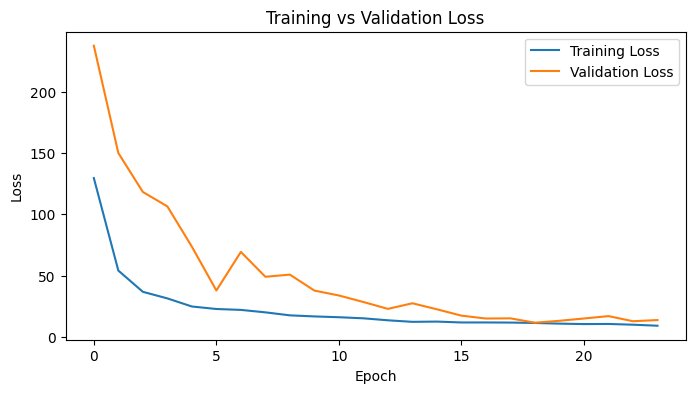

In [32]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

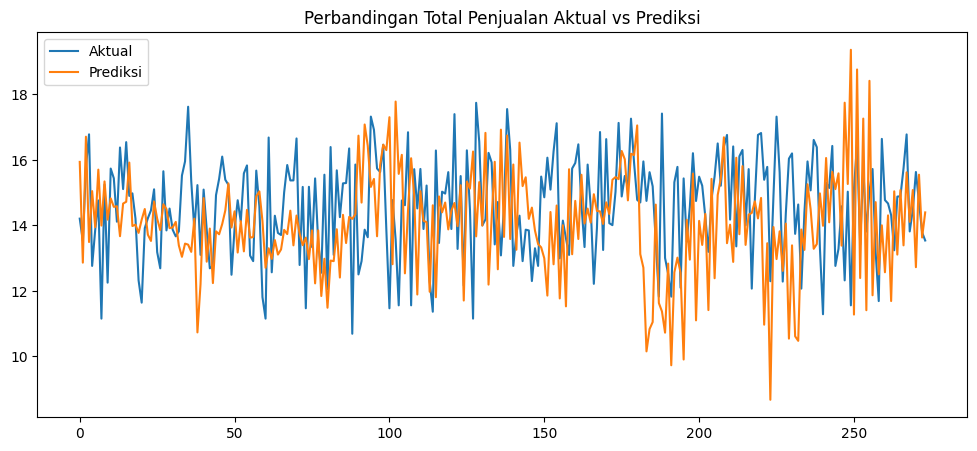

In [33]:
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Aktual')
plt.plot(y_pred, label='Prediksi')
plt.legend()
plt.title('Perbandingan Total Penjualan Aktual vs Prediksi')
plt.show()


In [34]:
n_future = 30

# Initialize last_window with the correct 3 features: tipe_barang_code, qty, and target.
# This matches the input structure (X_train) the model was trained on.
last_window = df_models[['tipe_barang_code','qty','target']].values[-window_size:].copy()
future_predictions = []

for i in range(n_future):
  # Reshape input_data to (1, window_size, 3) to match model's expected input (3 features).
  input_data = last_window[-window_size:].reshape(1, window_size, 3)

  # Use the already trained 'model' object for prediction, not build_model() again.
  pred_log = model.predict(input_data, verbose=0)[0][0]
  future_predictions.append(pred_log)

  # Construct next_row to maintain the 3-feature structure for the next iteration.
  # We'll assume 'tipe_barang_code' and 'qty' repeat from the last known entry
  # and the predicted 'pred_log' becomes the new 'target'.
  next_tipe_barang_code = last_window[-1, 0] # Get last known tipe_barang_code

  idx = i % window_size
  next_qty = last_window[idx, 1]

  # next_qty = last_window[:, 1].mean()              # Get last known qty
  next_row = np.array([next_tipe_barang_code, next_qty, pred_log])

  # Slide the window: remove the oldest row and add the new row
  last_window = np.vstack([last_window[1:], next_row])

future_preds_real = np.expm1(future_predictions)

# For plotting, get the actual last 30 values from df_models['total']
actual_last_30 = df_models['total'].values[-window_size:]

In [35]:
start_date = df_models.index[-1] + pd.DateOffset(days=1)
future_dates = pd.date_range(start=start_date, periods=n_future, freq='D')

future_df = pd.DataFrame({
    'tanggal': future_dates,
    'prediksi_penjualan': future_preds_real
})

future_df.set_index('tanggal',inplace=True)

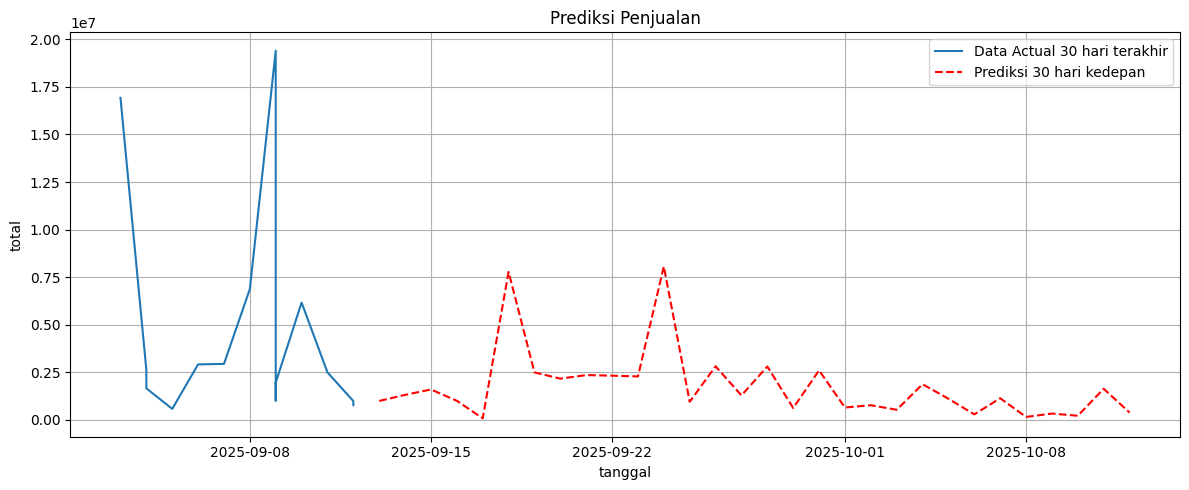

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(df_models.index[-15:], np.expm1(df_models['target'].iloc[-15:]), label='Data Actual 30 hari terakhir')
plt.plot(future_df.index, future_df['prediksi_penjualan'], label='Prediksi 30 hari kedepan', color='red', linestyle='--')
plt.xlabel('tanggal')
plt.ylabel('total')
plt.title('Prediksi Penjualan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
#PREDIKSI 30 HARI KEDEPAN VERSI 2

n_future = 30

# Initialize last_window with the correct 3 features: tipe_barang_code, qty, and target.
# This matches the input structure (X_train) the model was trained on.
last_window = df_models[['tipe_barang_code','qty','target']].values[-window_size:].copy()
future_predictions = []

for i in range(n_future):
  # Reshape input_data to (1, window_size, 3) to match model's expected input (3 features).
  input_data = last_window[-window_size:].reshape(1, window_size, 3)

  # Use the already trained 'model' object for prediction, not build_model() again.
  pred_log = model.predict(input_data, verbose=0)[0][0]
  future_predictions.append(pred_log)

  # Construct next_row to maintain the 3-feature structure for the next iteration.
  # We'll assume 'tipe_barang_code' and 'qty' repeat from the last known entry
  # and the predicted 'pred_log' becomes the new 'target'.
  next_tipe_barang_code = last_window[-1, 0] # Get last known tipe_barang_code

  # The original `next_qty` was `last_window[idx, 1]` which causes the `idx` to exceed bounds for `last_window`.
  # We should use `last_window[-1, 1]` for the last known `qty` to maintain consistency for the next prediction.
  # Alternatively, if `qty` is also dynamic/predicted, it would require a more complex model or assumption.
  # For now, let's assume `qty` also repeats from the last known entry.
  next_qty = last_window[-1, 1] # Get last known qty

  next_row = np.array([next_tipe_barang_code, next_qty, pred_log])

  # Slide the window: remove the oldest row and add the new row
  last_window = np.vstack([last_window[1:], next_row])

future_preds_real = np.expm1(future_predictions)

In [38]:
start_date = df_models.index[-1] + pd.DateOffset(days=1)
future_dates = pd.date_range(start=start_date, periods=n_future, freq='D')

future_df = pd.DataFrame({
    'tanggal': future_dates,
    'prediksi_penjualan': future_preds_real
})

future_df.set_index('tanggal',inplace=True)

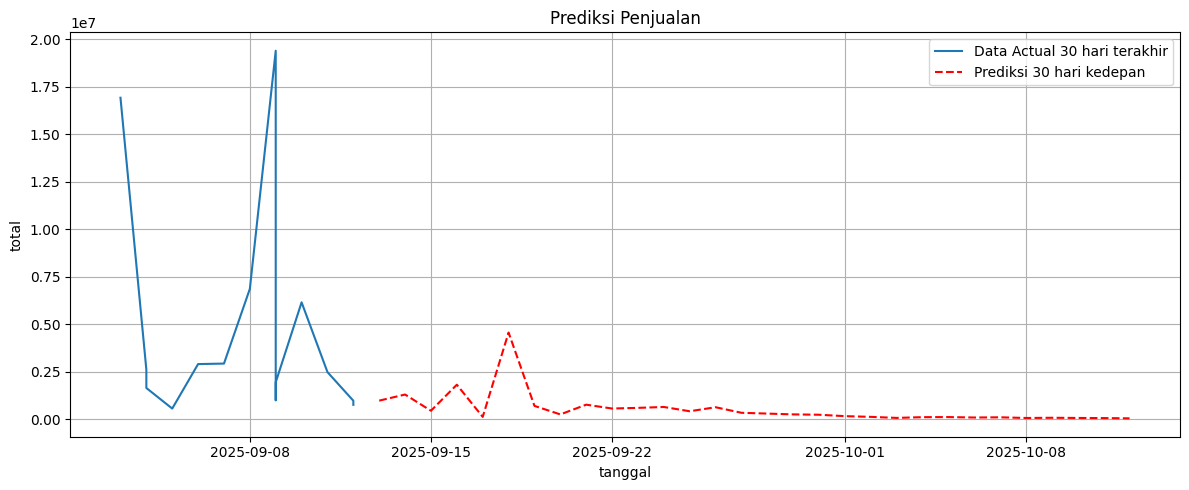

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(df_models.index[-15:], np.expm1(df_models['target'].iloc[-15:]), label='Data Actual 30 hari terakhir')
plt.plot(future_df.index, future_df['prediksi_penjualan'], label='Prediksi 30 hari kedepan', color='red', linestyle='--')
plt.xlabel('tanggal')
plt.ylabel('total')
plt.title('Prediksi Penjualan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()